<a href="https://colab.research.google.com/github/meherajmithun/CPVision-AI/blob/main/Phase3_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

The required libraries are imported for data manipulation and visualization.

In [ ]:
#first check the dataset is uploaded or not through file upload
# import os

# print(os.listdir())

df = pd.read_csv("cpvision_dataset.csv") #Read the CSV file into a Pandas DataFrame.


['.config', 'cpvision_dataset.csv', 'sample_data']


In [ ]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Shape: (7185, 6)

Columns:
Index(['contest_id', 'problem_index', 'problem_name', 'statement', 'tags',
       'rating'],
      dtype='object')

Data Types:
contest_id        int64
problem_index    object
problem_name     object
statement        object
tags             object
rating            int64
dtype: object


The dataset shape and data types are examined to understand the overall structure before analysis.

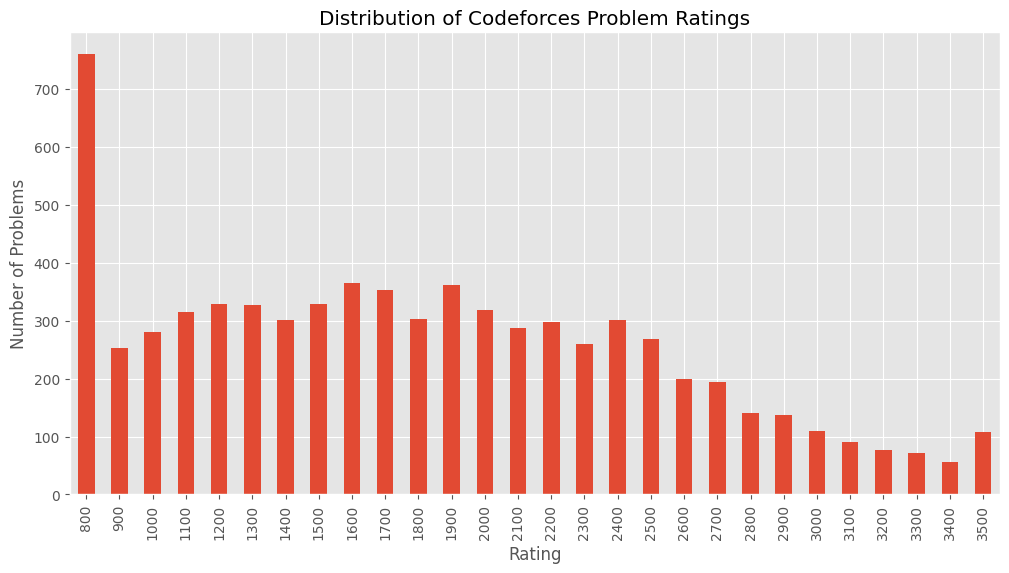

In [ ]:
plt.figure(figsize=(12,6))

df["rating"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Codeforces Problem Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Problems")

plt.show()

Questions this graph answers
Which rating appears most?

*   Which rating appears most?
*   Is the dataset balanced?
Is the dataset balanced?
Are difficult problems fewer?

The rating distribution is analyzed to determine whether the dataset contains a balanced number of problems across different difficulty levels.

In [ ]:
from collections import Counter

tag_counter = Counter()

for tags in df["tags"]:
    tag_counter.update(tags)

print(tag_counter.most_common(10))

[('greedy', 2404), ('math', 2327), ('implementation', 2114), ('dp', 1674), ('data structures', 1400), ('brute force', 1400), ('constructive algorithms', 1390), ('binary search', 873), ('sortings', 871), ('graphs', 811)]


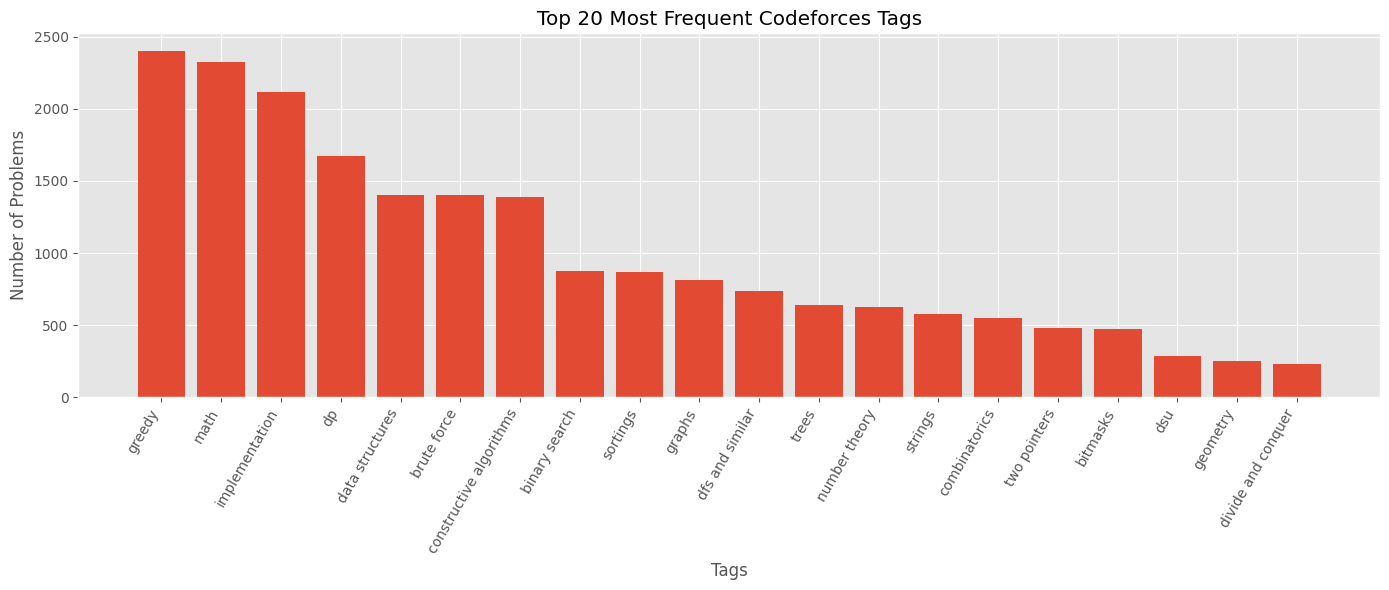

In [ ]:
top20 = tag_counter.most_common(20)

tags = [x[0] for x in top20]
counts = [x[1] for x in top20]

import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.bar(tags, counts)

plt.xticks(rotation=60, ha='right')

plt.title("Top 20 Most Frequent Codeforces Tags")
plt.xlabel("Tags")
plt.ylabel("Number of Problems")

plt.tight_layout()
plt.show()

Tag frequency analysis identifies the most common algorithmic topics present in the dataset

In [ ]:
df["statement_length"] = df["statement"].str.len() #Statement Length
df["statement_length"].describe() #Look at statistics.



,statement_length
count,7185.000000
mean,845.034099
std,408.583141
min,103.000000
25%,548.000000
50%,773.000000
75%,1073.000000
max,3780.000000


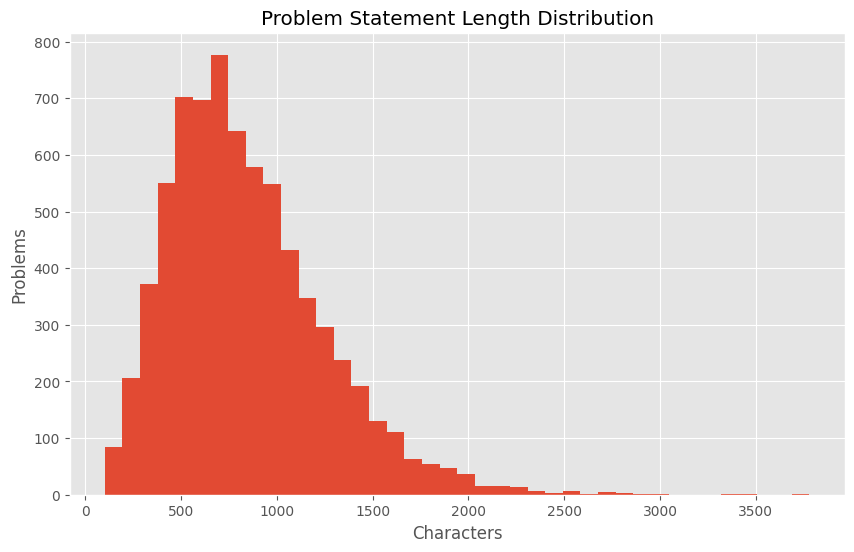

In [ ]:
# Plot histogram.
plt.figure(figsize=(10,6))

plt.hist(df["statement_length"], bins=40)

plt.title("Problem Statement Length Distribution")

plt.xlabel("Characters")

plt.ylabel("Problems")

plt.show()

Statement length analysis helps determine the average size of problem descriptions and assists in selecting an appropriate maximum sequence length for transformer models.

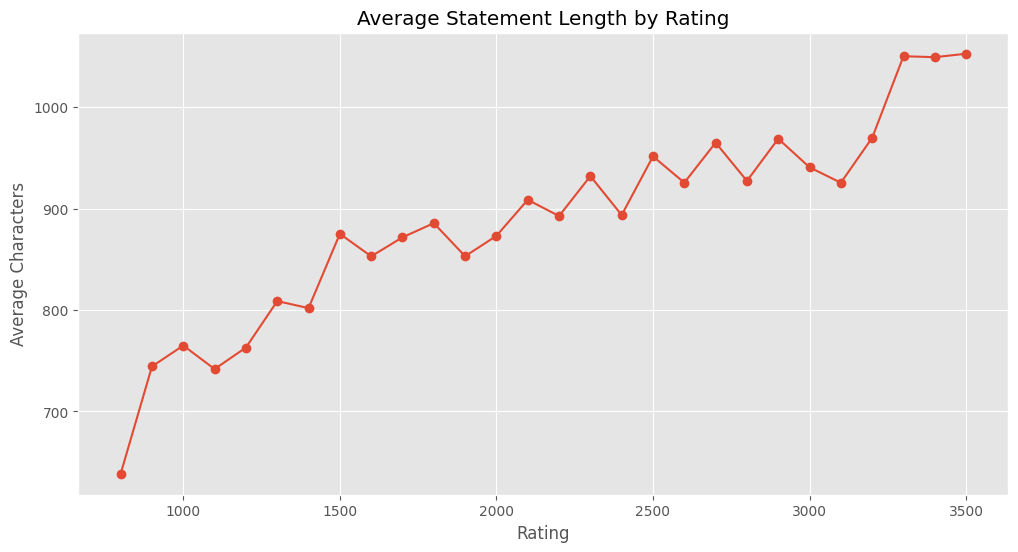

In [ ]:
average_length = df.groupby("rating")["statement_length"].mean()

plt.figure(figsize=(12,6))

average_length.plot(marker="o")

plt.title("Average Statement Length by Rating")

plt.xlabel("Rating")

plt.ylabel("Average Characters")

plt.grid(True)

plt.show()

Questions answered

Do harder problems have longer statements?
Does statement length correlate with difficulty?

In [ ]:
unique_tags = set()

for tags in df["tags"]:
    unique_tags.update(tags)

print("Total Unique Tags:", len(unique_tags))

print(sorted(unique_tags))

Total Unique Tags: 36
['2-sat', 'binary search', 'bitmasks', 'brute force', 'chinese remainder theorem', 'combinatorics', 'constructive algorithms', 'data structures', 'dfs and similar', 'divide and conquer', 'dp', 'dsu', 'expression parsing', 'fft', 'flows', 'games', 'geometry', 'graph matchings', 'graphs', 'greedy', 'hashing', 'implementation', 'interactive', 'math', 'matrices', 'meet-in-the-middle', 'number theory', 'probabilities', 'schedules', 'shortest paths', 'sortings', 'string suffix structures', 'strings', 'ternary search', 'trees', 'two pointers']


This step determines the total number of distinct algorithmic topics that the tag prediction model will learn.

In [ ]:
# Problems per Tag
for tag, count in tag_counter.most_common():
    print(f"{tag:30} {count}")

greedy                         2404
math                           2327
implementation                 2114
dp                             1674
data structures                1400
brute force                    1400
constructive algorithms        1390
binary search                  873
sortings                       871
graphs                         811
dfs and similar                737
trees                          640
number theory                  624
strings                        580
combinatorics                  548
two pointers                   478
bitmasks                       474
dsu                            288
geometry                       250
divide and conquer             232
shortest paths                 203
games                          176
probabilities                  163
hashing                        162
interactive                    158
flows                          94
matrices                       89
fft                            68
string suffix st

In [ ]:
df.to_csv("cpvision_dataset_eda.csv", index=False) # Save Updated Dataset